<a href="https://colab.research.google.com/github/yogasriram2012-hub/high-altitude-anti-drone-SIH/blob/main/env_model/env_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ISA Scenario Summary:

Scenario                    Alt(m)    Temp(C)     Pressure(Pa)    Density(kg/m3)
moderate_altitude_3000m     3000      -4.50       70108.3         0.9091
high_altitude_4500m         4500      -14.25      57728.0         0.7768
extreme_altitude_6000m      6000      -24.00      47180.6         0.6597

Generating plots...


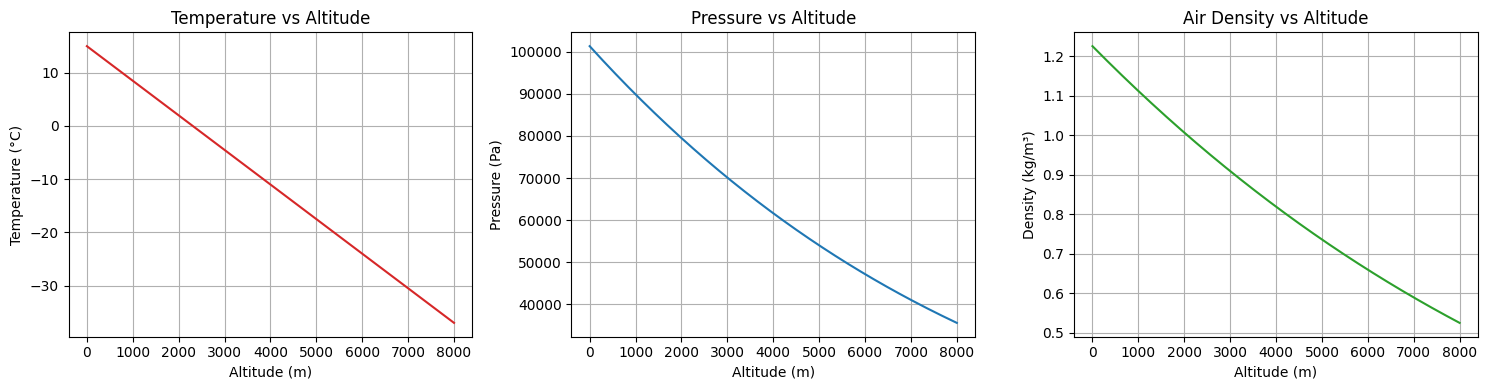

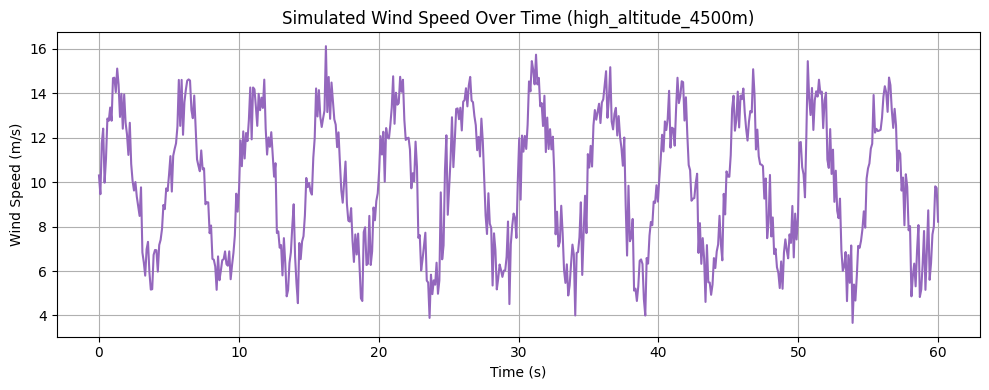


Day 2 complete. Files saved: isa_profile.png, wind_gust.png


In [1]:
"""
Day 2 - Environmental Model
High Altitude Anti-Drone System Simulation (SIH Problem Statement 26050)

This module computes temperature, pressure, and air density as a function
of altitude using the International Standard Atmosphere (ISA) model, and
generates a wind-gust disturbance signal. Together these outputs act as
the "environment generator" that feeds disturbance into the Day 3 control
loop and Day 4 tracking modules.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. ISA Constants (Troposphere, 0 to 11,000 m)
# ---------------------------------------------------------
T0 = 288.15        # Sea level standard temperature (K)
P0 = 101325.0       # Sea level standard pressure (Pa)
L = 0.0065         # Temperature lapse rate (K/m)
R = 287.05         # Specific gas constant for dry air (J/(kg*K))
G = 9.80665        # Gravitational acceleration (m/s^2)


def isa_temperature(altitude_m):
    """Temperature (Kelvin) at a given altitude using ISA lapse rate."""
    return T0 - L * altitude_m


def isa_pressure(altitude_m):
    """Pressure (Pa) at a given altitude using the ISA barometric formula."""
    temp = isa_temperature(altitude_m)
    return P0 * (temp / T0) ** (G / (R * L))


def isa_density(altitude_m):
    """Air density (kg/m^3) at a given altitude, from ideal gas law."""
    pressure = isa_pressure(altitude_m)
    temp = isa_temperature(altitude_m)
    return pressure / (R * temp)


def temperature_celsius(altitude_m):
    """Convenience: temperature in Celsius instead of Kelvin."""
    return isa_temperature(altitude_m) - 273.15


# ---------------------------------------------------------
# 2. Wind Gust Model
# ---------------------------------------------------------
def wind_gust_model(time_s, base_wind_speed=8.0, gust_amplitude=4.0,
                     gust_freq=0.2, noise_std=1.0, seed=42):
    """
    Generates a wind speed signal over time combining:
    - a constant base wind speed (m/s)
    - a sinusoidal gust component (simulates periodic gusting)
    - random turbulence noise

    time_s: 1D numpy array of time values in seconds
    Returns: 1D numpy array of wind speed (m/s), same length as time_s
    """
    rng = np.random.default_rng(seed)
    sinusoidal_gust = gust_amplitude * np.sin(2 * np.pi * gust_freq * time_s)
    turbulence = rng.normal(0, noise_std, size=len(time_s))
    wind_speed = base_wind_speed + sinusoidal_gust + turbulence
    return np.clip(wind_speed, 0, None)  # wind speed can't be negative


# ---------------------------------------------------------
# 3. High-Altitude Scenario Presets
# ---------------------------------------------------------
# Realistic reference points for Ladakh/Siachen-type terrain.
# Use these to sanity-check your numbers and later as dashboard presets.
SCENARIOS = {
    "moderate_altitude_3000m": {"altitude_m": 3000, "base_wind": 6.0},
    "high_altitude_4500m":     {"altitude_m": 4500, "base_wind": 10.0},
    "extreme_altitude_6000m":  {"altitude_m": 6000, "base_wind": 15.0},
}


def print_scenario_summary():
    """Prints temp/pressure/density for each preset scenario."""
    print(f"{'Scenario':<28}{'Alt(m)':<10}{'Temp(C)':<12}{'Pressure(Pa)':<16}{'Density(kg/m3)'}")
    for name, params in SCENARIOS.items():
        alt = params["altitude_m"]
        temp_c = temperature_celsius(alt)
        pressure = isa_pressure(alt)
        density = isa_density(alt)
        print(f"{name:<28}{alt:<10}{temp_c:<12.2f}{pressure:<16.1f}{density:.4f}")


# ---------------------------------------------------------
# 4. Plots (run these in Colab to visually verify the model)
# ---------------------------------------------------------
def plot_isa_profile():
    """Plots temperature, pressure, and density vs altitude (0-8000m)."""
    altitudes = np.linspace(0, 8000, 200)
    temps = [temperature_celsius(a) for a in altitudes]
    pressures = [isa_pressure(a) for a in altitudes]
    densities = [isa_density(a) for a in altitudes]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].plot(altitudes, temps, color="tab:red")
    axs[0].set_title("Temperature vs Altitude")
    axs[0].set_xlabel("Altitude (m)")
    axs[0].set_ylabel("Temperature (°C)")
    axs[0].grid(True)

    axs[1].plot(altitudes, pressures, color="tab:blue")
    axs[1].set_title("Pressure vs Altitude")
    axs[1].set_xlabel("Altitude (m)")
    axs[1].set_ylabel("Pressure (Pa)")
    axs[1].grid(True)

    axs[2].plot(altitudes, densities, color="tab:green")
    axs[2].set_title("Air Density vs Altitude")
    axs[2].set_xlabel("Altitude (m)")
    axs[2].set_ylabel("Density (kg/m³)")
    axs[2].grid(True)

    plt.tight_layout()
    plt.savefig("isa_profile.png", dpi=150)
    plt.show()


def plot_wind_gust(altitude_label="high_altitude_4500m"):
    """Plots a simulated wind speed signal over 60 seconds for a scenario."""
    time_s = np.linspace(0, 60, 600)
    base_wind = SCENARIOS[altitude_label]["base_wind"]
    wind = wind_gust_model(time_s, base_wind_speed=base_wind)

    plt.figure(figsize=(10, 4))
    plt.plot(time_s, wind, color="tab:purple")
    plt.title(f"Simulated Wind Speed Over Time ({altitude_label})")
    plt.xlabel("Time (s)")
    plt.ylabel("Wind Speed (m/s)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("wind_gust.png", dpi=150)
    plt.show()


# ---------------------------------------------------------
# 5. Run everything
# ---------------------------------------------------------
if __name__ == "__main__":
    print("ISA Scenario Summary:\n")
    print_scenario_summary()
    print("\nGenerating plots...")
    plot_isa_profile()
    plot_wind_gust()
    print("\nDay 2 complete. Files saved: isa_profile.png, wind_gust.png")